# PowerGrid Utility Intelligence - Capstone Project Notebook

**Objective:** Predict grid failures, analyze asset health, and formulate risk-based predictive maintenance strategies for electrical utility assets.

---

## 1. Setup & Environment Initialization

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Import pipeline modules from package
sys.path.append(os.path.abspath('../'))
from powergrid_capstone.main import main
from powergrid_capstone.config import OUTPUT_DIR, RAW_DATA_PATH
from powergrid_capstone.data_preprocessing import load_raw_dataset, clean_dataset

## 2. Execute Complete Pipeline
Run the complete modular pipeline to preprocess data, train models, score financial risks, and export artifacts.

In [2]:
main()

2026-09-01 13:52:40 [INFO] Main execution started at 2026-09-01 13:52:40
2026-09-01 13:52:40 [INFO] Loading raw dataset started at 2026-09-01 13:52:40
2026-09-01 13:52:40 [INFO] Loading raw dataset ended at 2026-09-01 13:52:40
2026-09-01 13:52:40 [INFO] Cleaning dataset started at 2026-09-01 13:52:40
2026-09-01 13:52:41 [INFO] Cleaning dataset ended at 2026-09-01 13:52:41
2026-09-01 13:52:41 [INFO] Saving clean dataset started at 2026-09-01 13:52:41
2026-09-01 13:52:41 [INFO] Saving clean dataset ended at 2026-09-01 13:52:41
2026-09-01 13:52:41 [INFO] Generating EDA report started at 2026-09-01 13:52:41
2026-09-01 13:52:41 [INFO] Generating EDA report ended at 2026-09-01 13:52:41
2026-09-01 13:52:41 [INFO] Generating EDA plots started at 2026-09-01 13:52:41
2026-09-01 13:52:43 [INFO] Generating EDA plots ended at 2026-09-01 13:52:43
2026-09-01 13:52:43 [INFO] Training all models started at 2026-09-01 13:52:43
2026-09-01 14:13:27 [INFO] Training all models ended at 2026-09-01 14:13:27
2

## 3. Exploratory Data Analysis (EDA) & Visualizations
Reviewing key asset distribution characteristics, failure rates by category and region, and feature correlation heatmaps.

--- Target Class Distribution ---


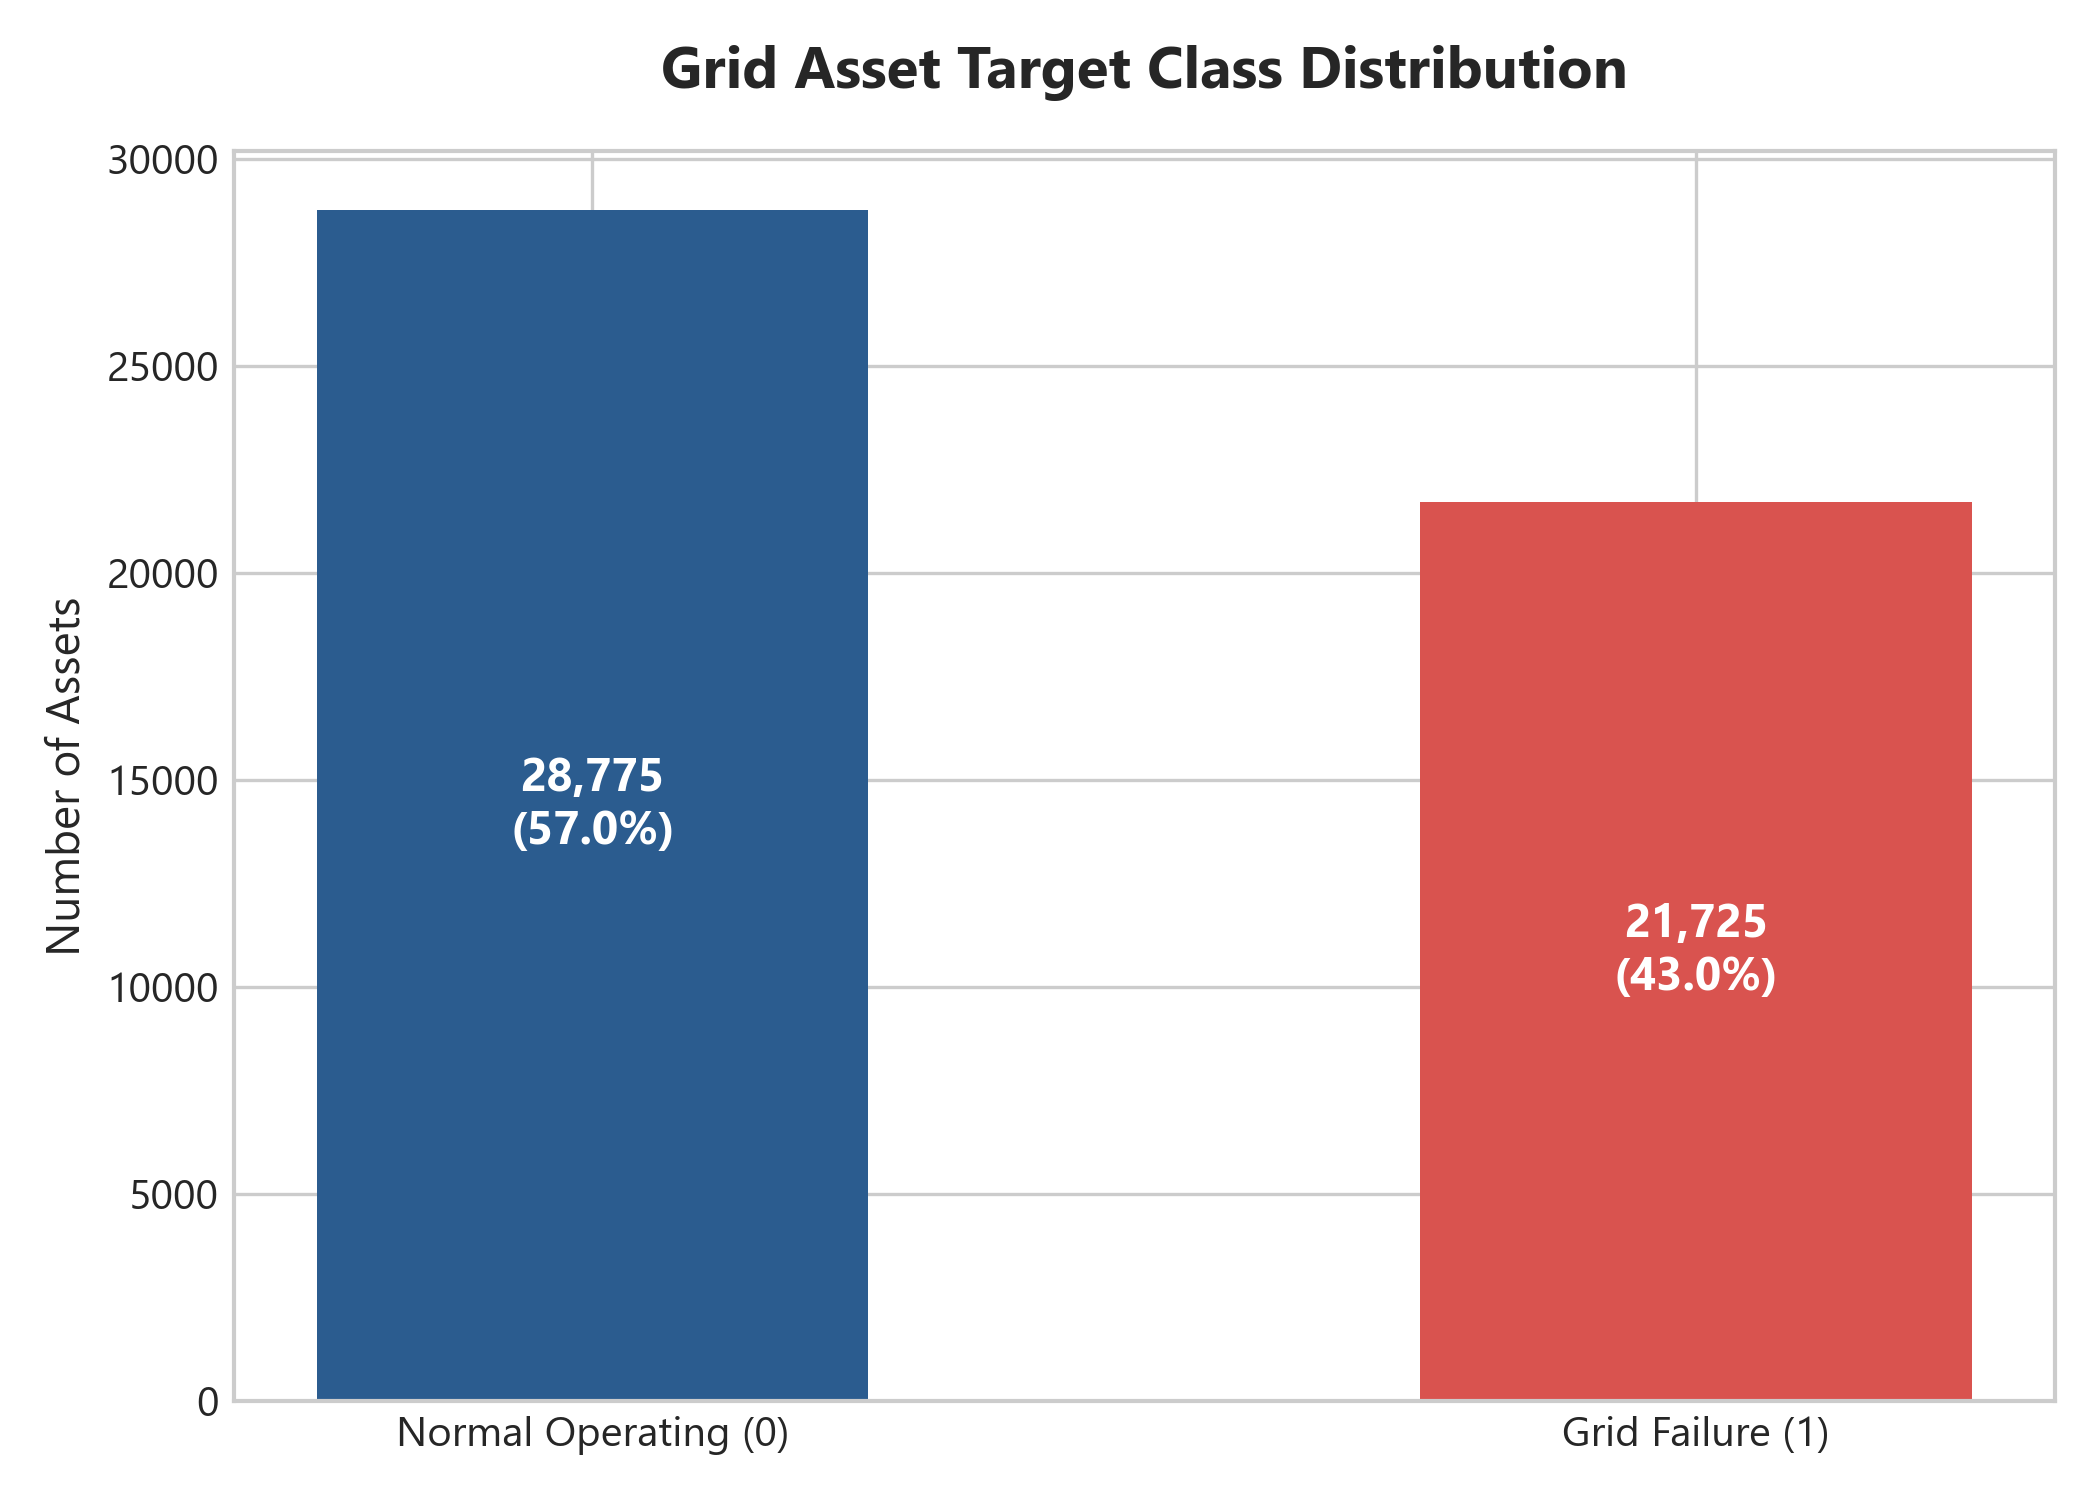

--- Failure Rate by Asset Type ---


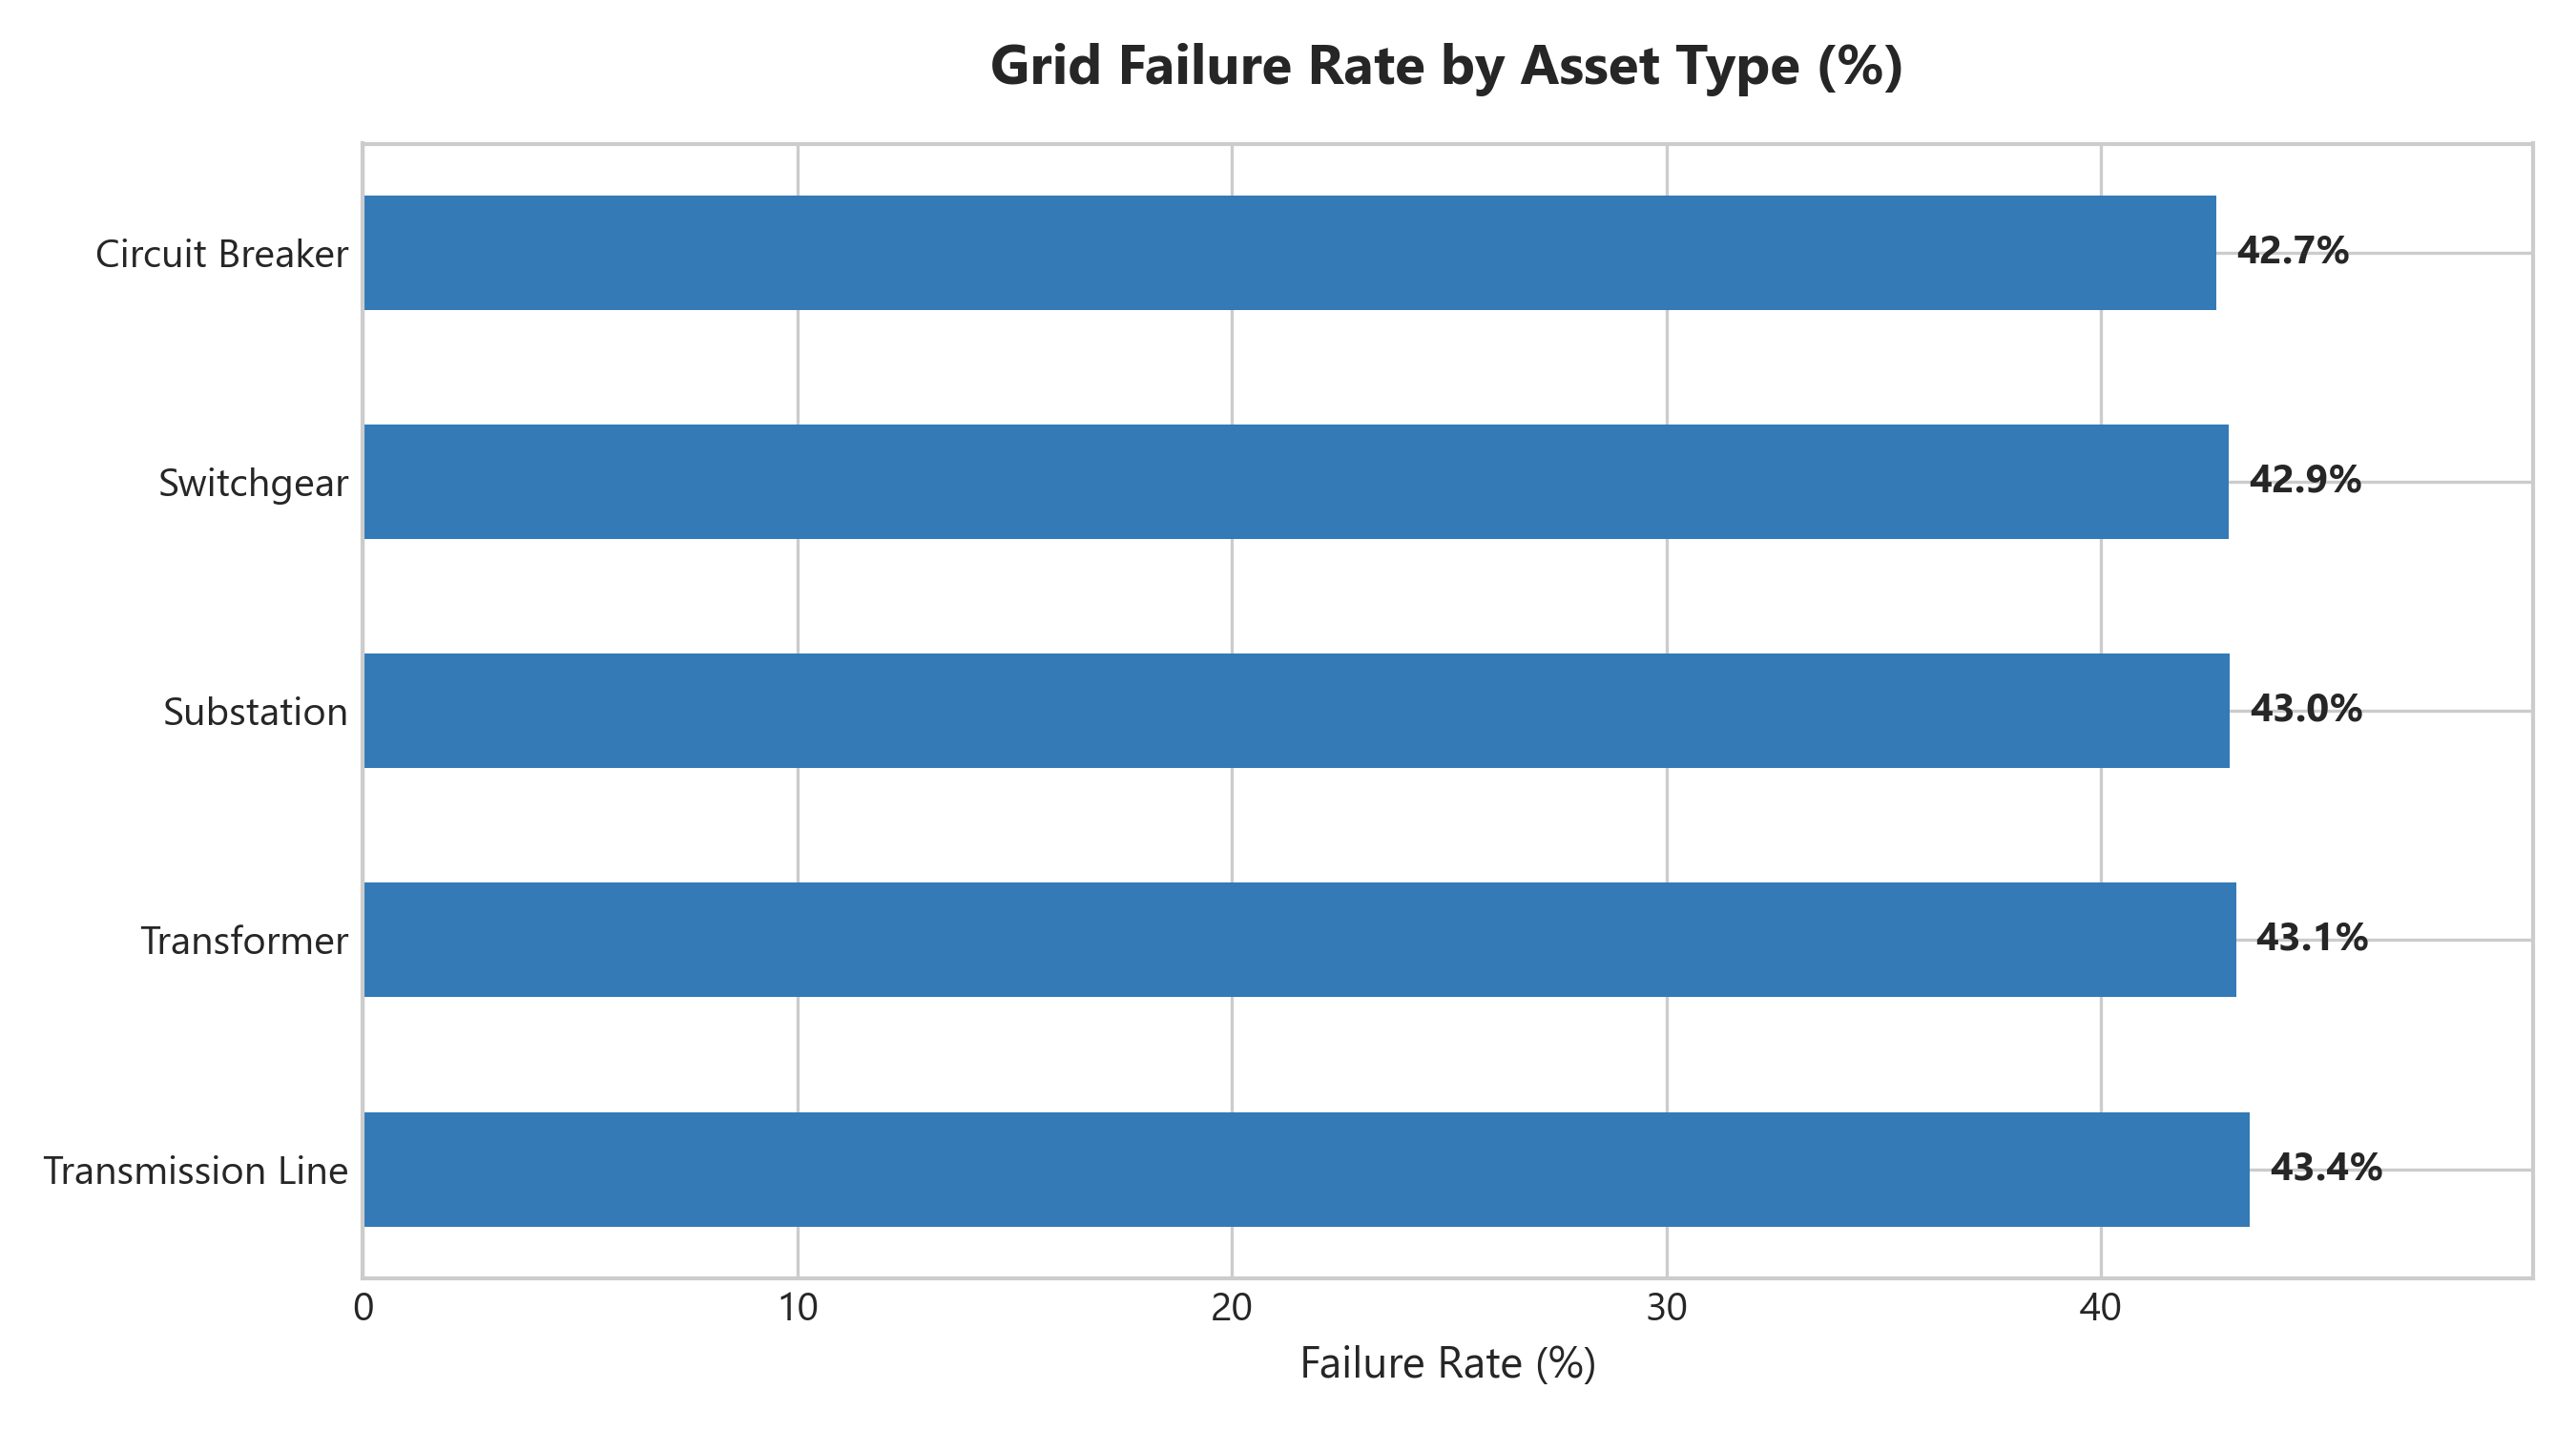

--- Failure Rate by Substation Region ---


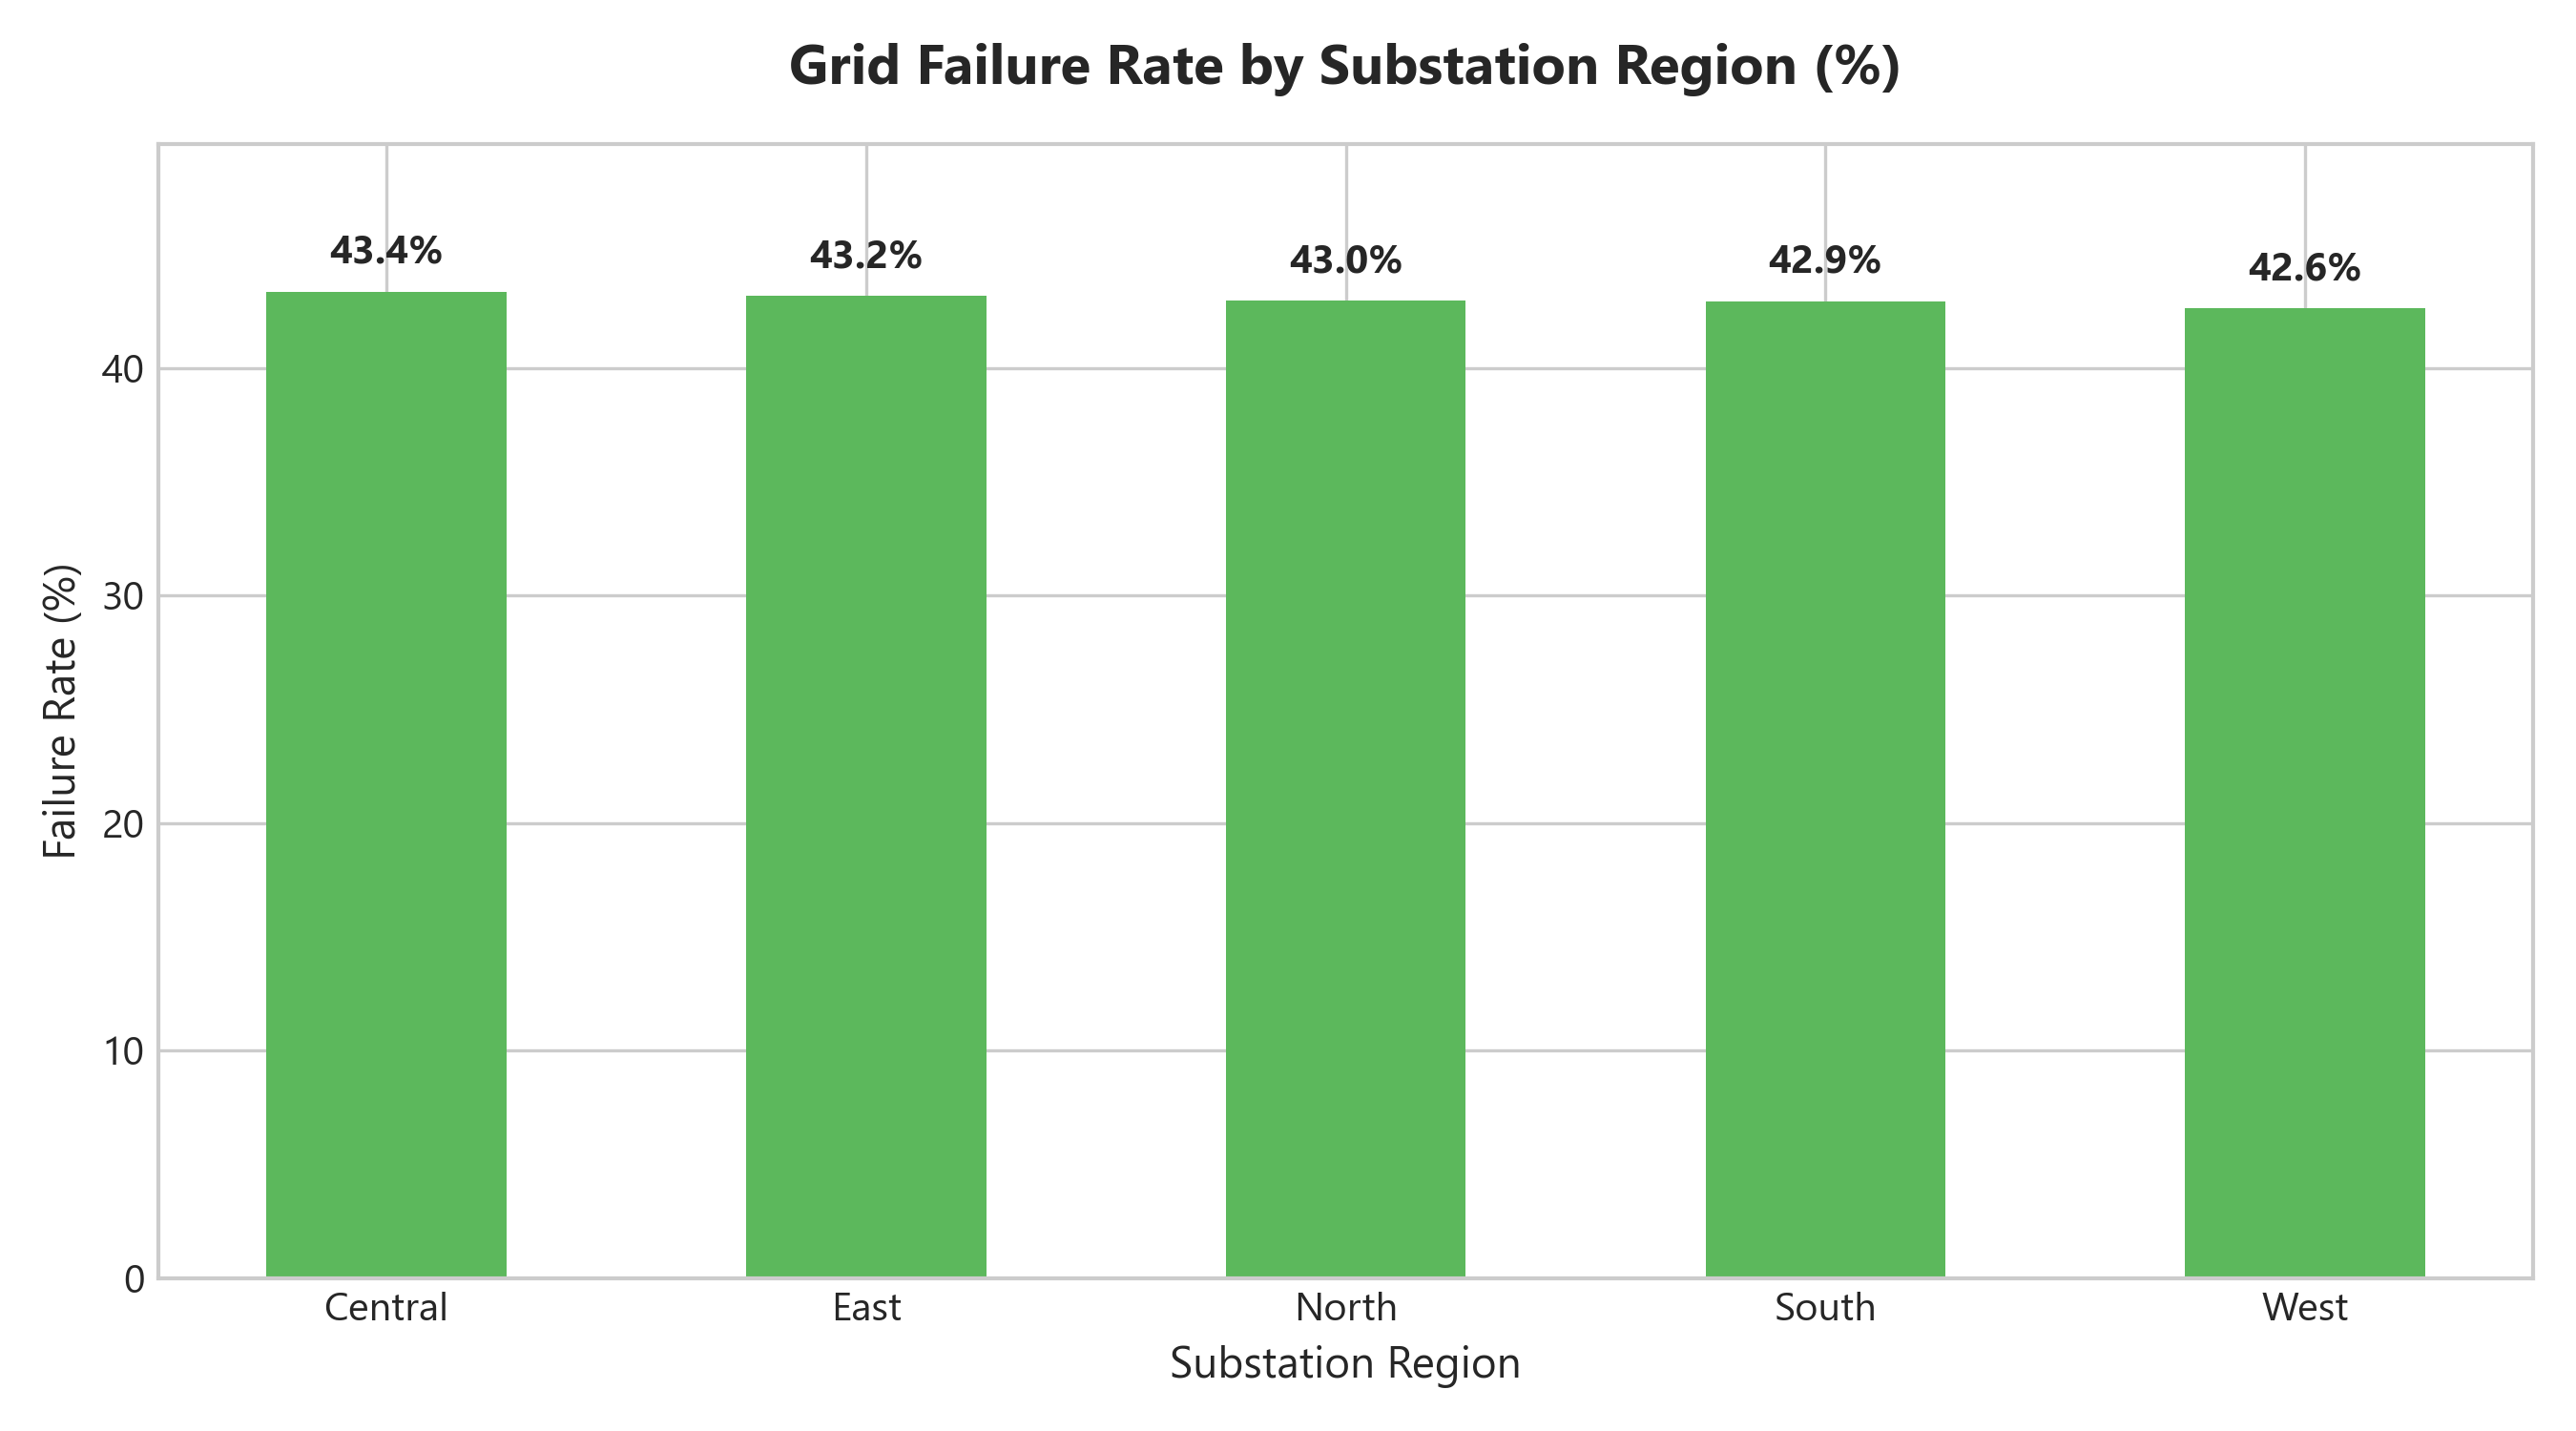

--- Correlation Heatmap ---


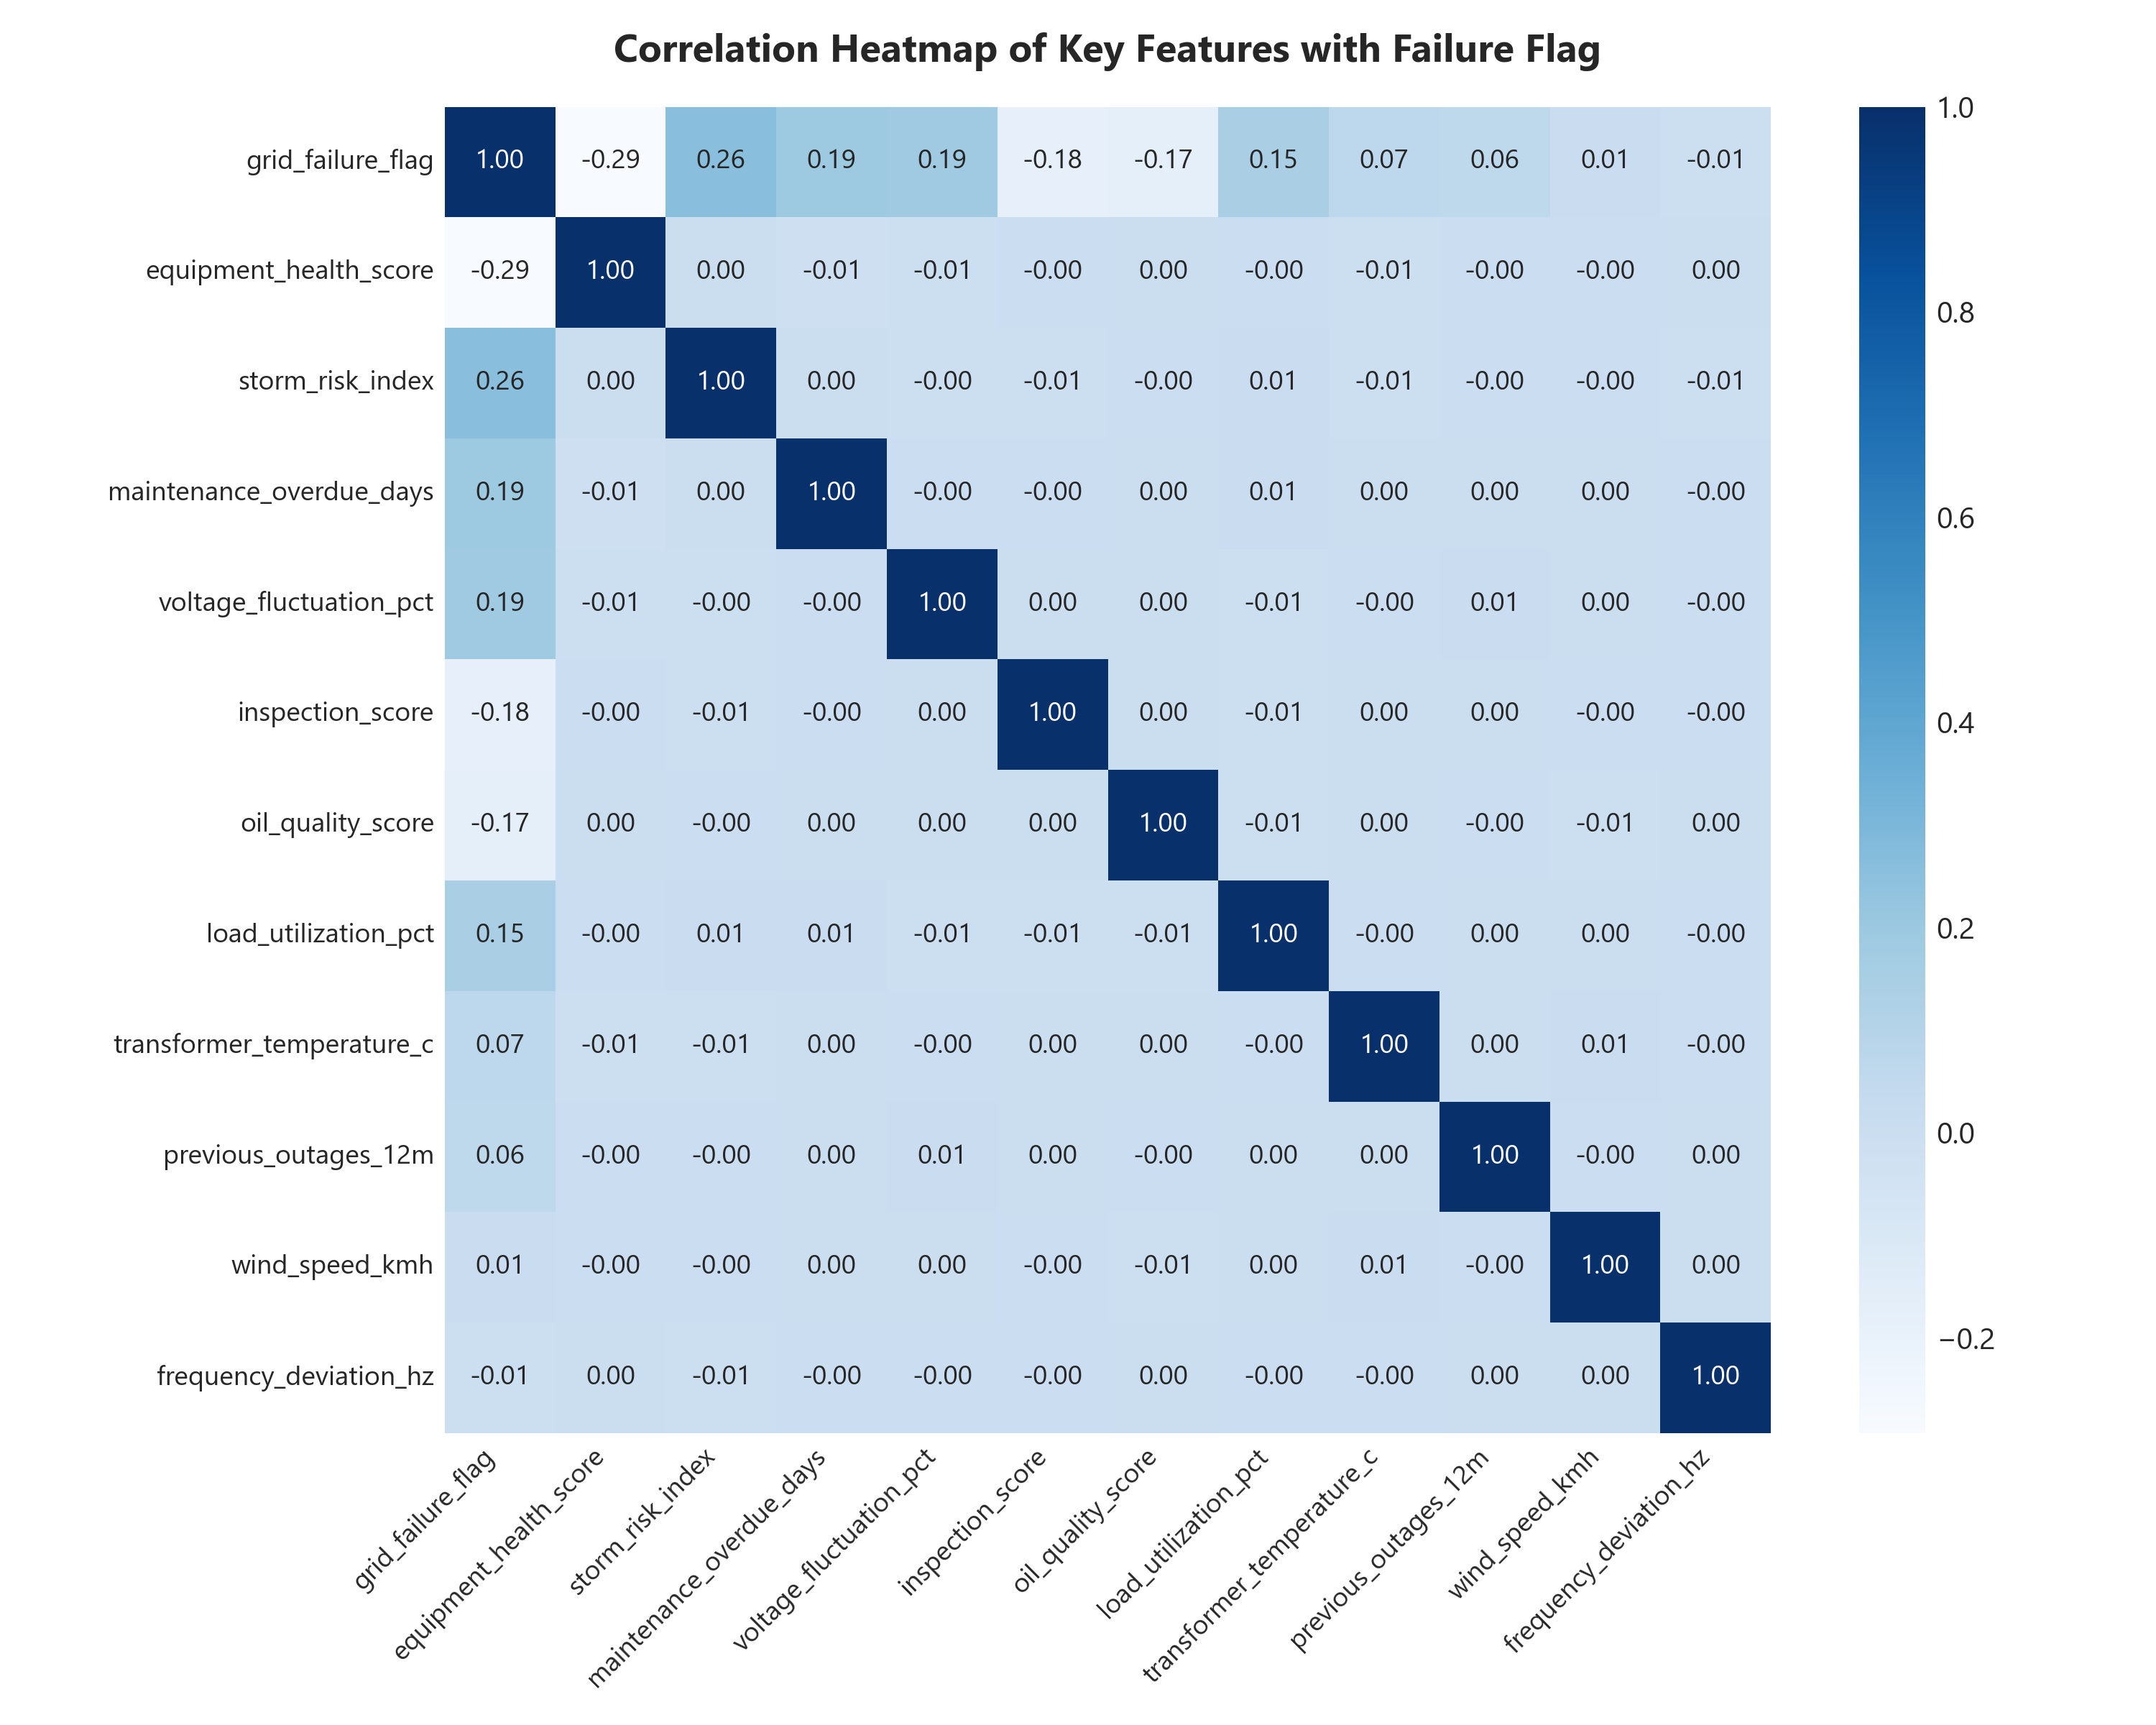

In [3]:
print('--- Target Class Distribution ---')
display(Image(filename=os.path.join(OUTPUT_DIR, 'eda_target_distribution.png')))

print('--- Failure Rate by Asset Type ---')
display(Image(filename=os.path.join(OUTPUT_DIR, 'eda_failure_rate_by_asset_type.png')))

print('--- Failure Rate by Substation Region ---')
display(Image(filename=os.path.join(OUTPUT_DIR, 'eda_failure_rate_by_region.png')))

print('--- Correlation Heatmap ---')
display(Image(filename=os.path.join(OUTPUT_DIR, 'eda_correlation_heatmap.png')))

## 4. Machine Learning Model Evaluation
Comparing classification algorithms (Logistic Regression, Decision Tree, Support Vector Machine, and Random Forest) using Stratified Cross-Validation and ROC-AUC.

,model,accuracy,precision,recall,f1,roc_auc
3,RandomForest,0.835149,0.823203,0.785501,0.803910,0.914449
2,SVM,0.771188,0.719087,0.768239,0.742851,0.853617
0,LogisticRegression,0.748713,0.693926,0.744074,0.718125,0.830888
1,DecisionTree,0.771287,0.734609,0.733257,0.733932,0.766628


--- Model ROC Curves Comparison ---


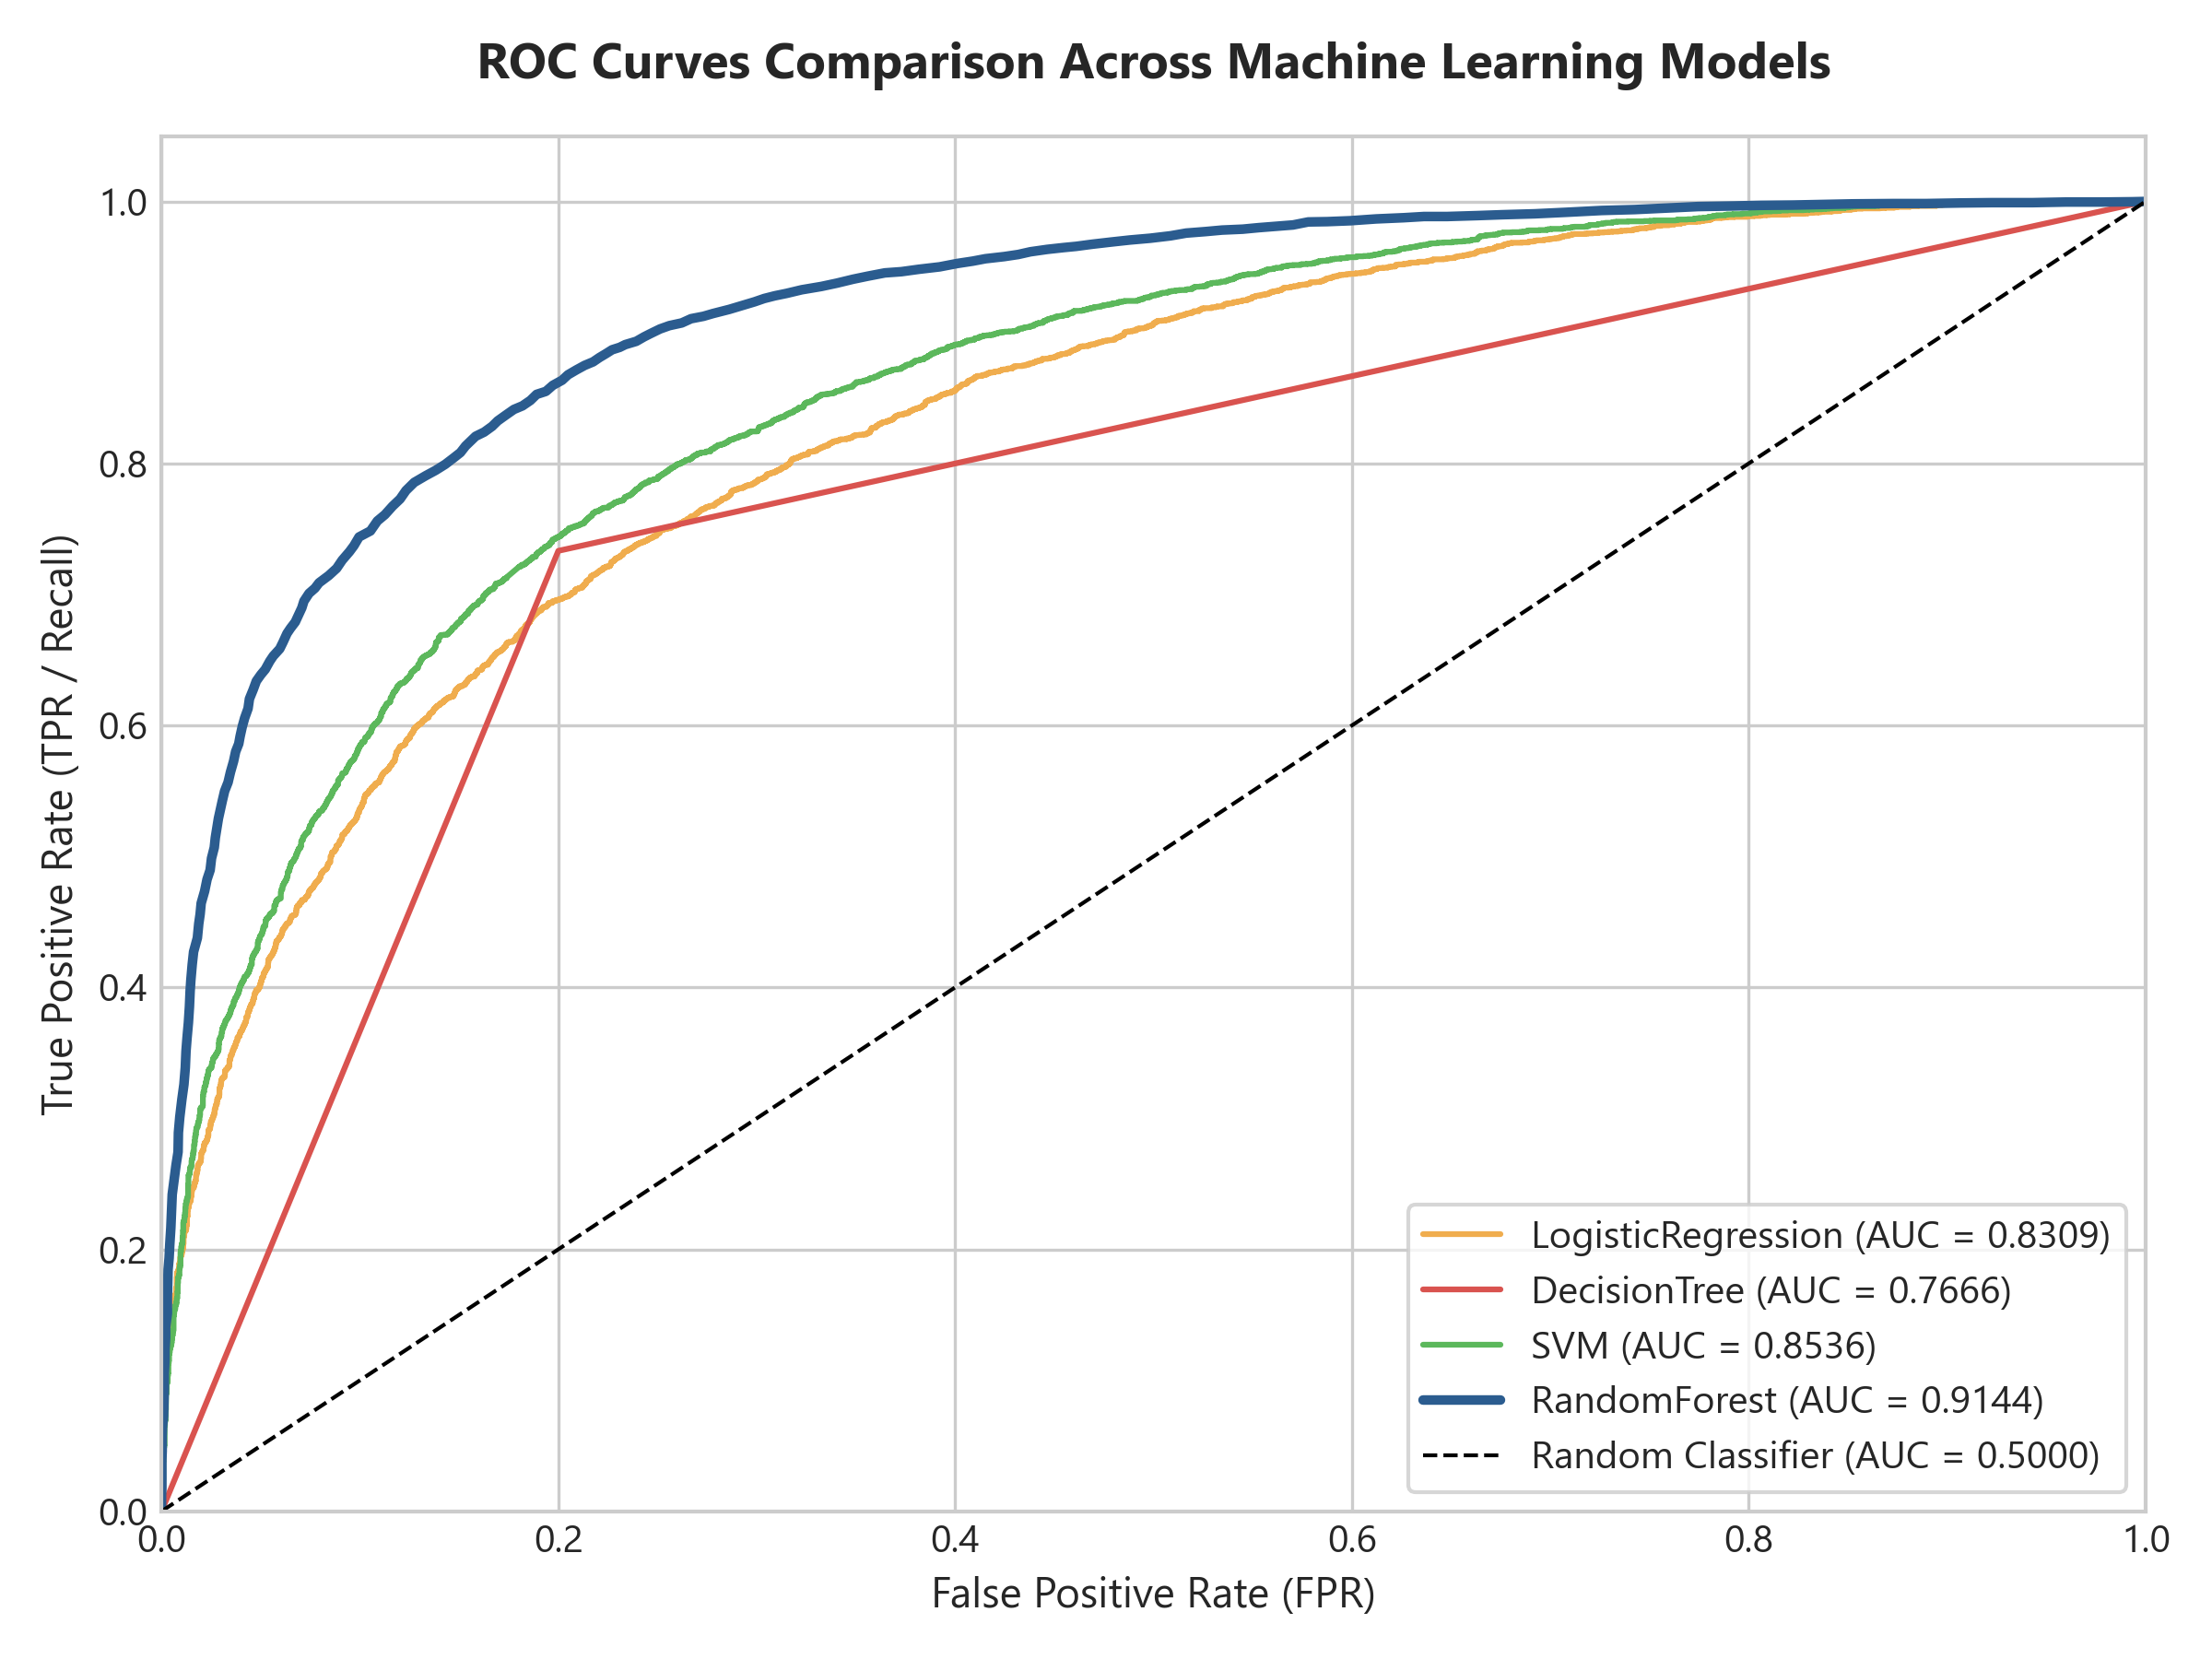

--- Best Model Confusion Matrix ---


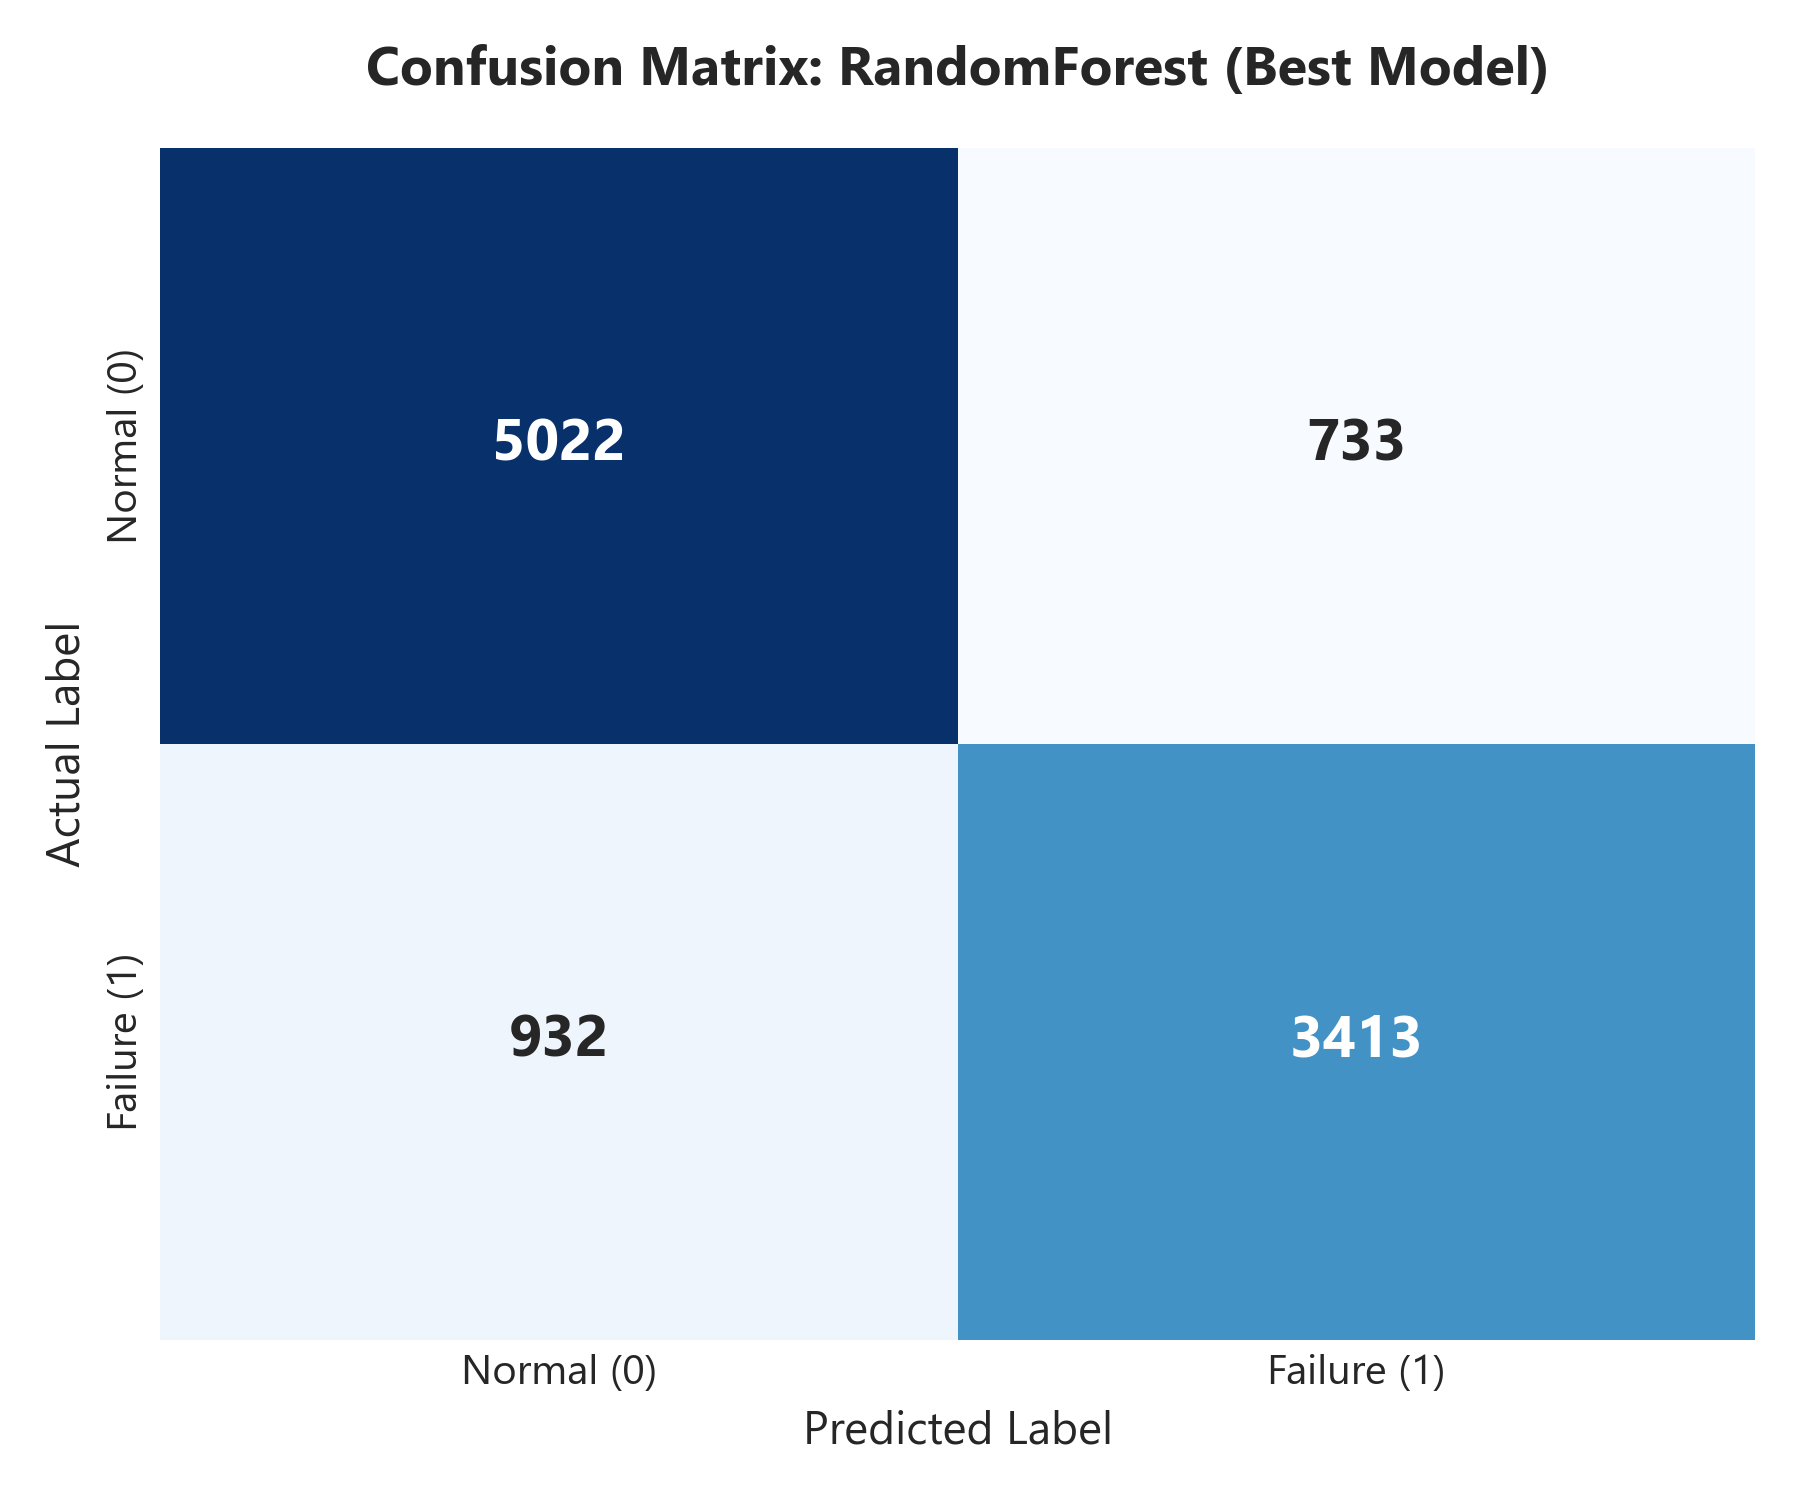

--- Feature Importance Analysis ---


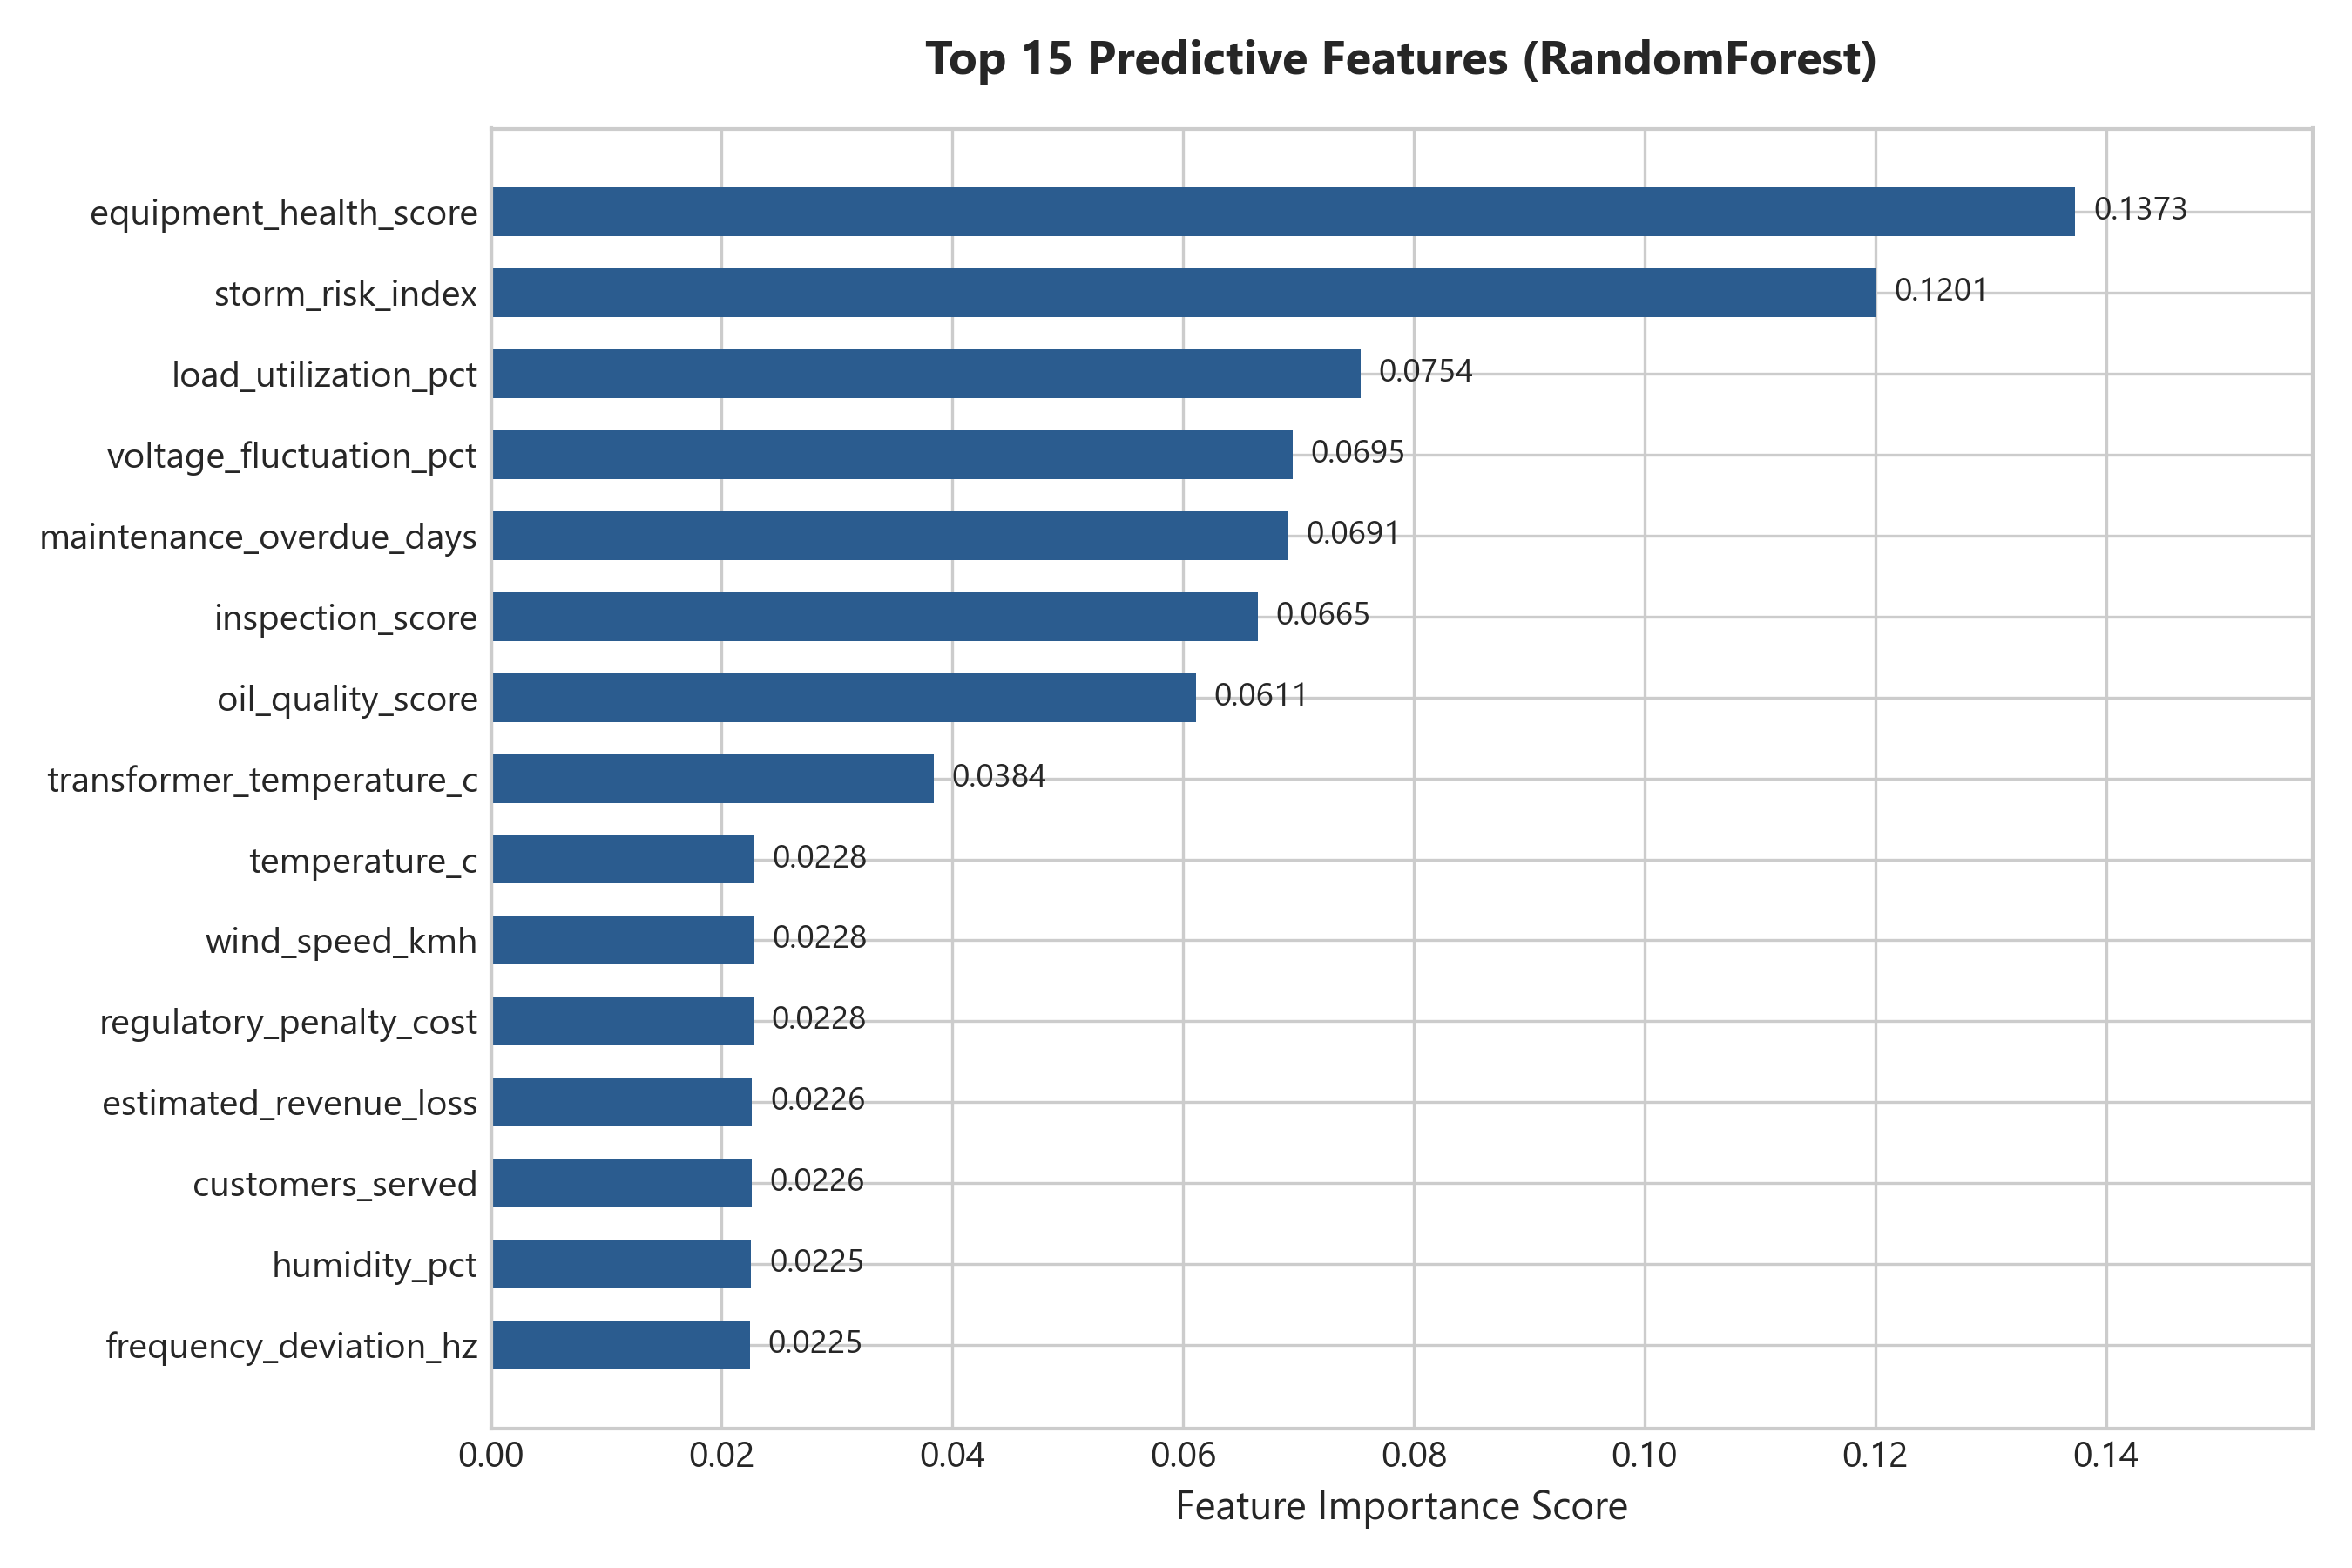

In [4]:
metrics_df = pd.read_csv(os.path.join(OUTPUT_DIR, 'model_metrics.csv'))
display(metrics_df.sort_values(by='roc_auc', ascending=False))

print('--- Model ROC Curves Comparison ---')
display(Image(filename=os.path.join(OUTPUT_DIR, 'model_roc_curves.png')))

print('--- Best Model Confusion Matrix ---')
display(Image(filename=os.path.join(OUTPUT_DIR, 'model_confusion_matrix.png')))

print('--- Feature Importance Analysis ---')
display(Image(filename=os.path.join(OUTPUT_DIR, 'model_feature_importance.png')))

## 5. Asset Risk Monetization & Priority Recommendations
Calculating financial risk exposure scores: RiskScore = P(Failure) * (EstimatedRevenueLoss + RegulatoryPenaltyCost).

,asset_type,substation_region,avg_failure_prob,total_expected_impact,avg_risk_score
16,Transformer,East,0.429459,2.235890e+09,442835.637362
12,Switchgear,North,0.425451,1.695948e+09,432613.649706
24,Transmission Line,West,0.426158,1.811359e+09,424232.691947
21,Transmission Line,East,0.438982,1.767487e+09,423786.802326
6,Substation,East,0.441830,1.826150e+09,407608.251968
17,Transformer,North,0.433772,1.972393e+09,405313.460395
1,Circuit Breaker,East,0.408074,1.796690e+09,389975.436746
0,Circuit Breaker,Central,0.438293,1.613442e+09,377042.731831
15,Transformer,Central,0.429278,1.933442e+09,376565.125580
3,Circuit Breaker,South,0.433021,1.621250e+09,372571.940472


--- Risk Score Distribution ---


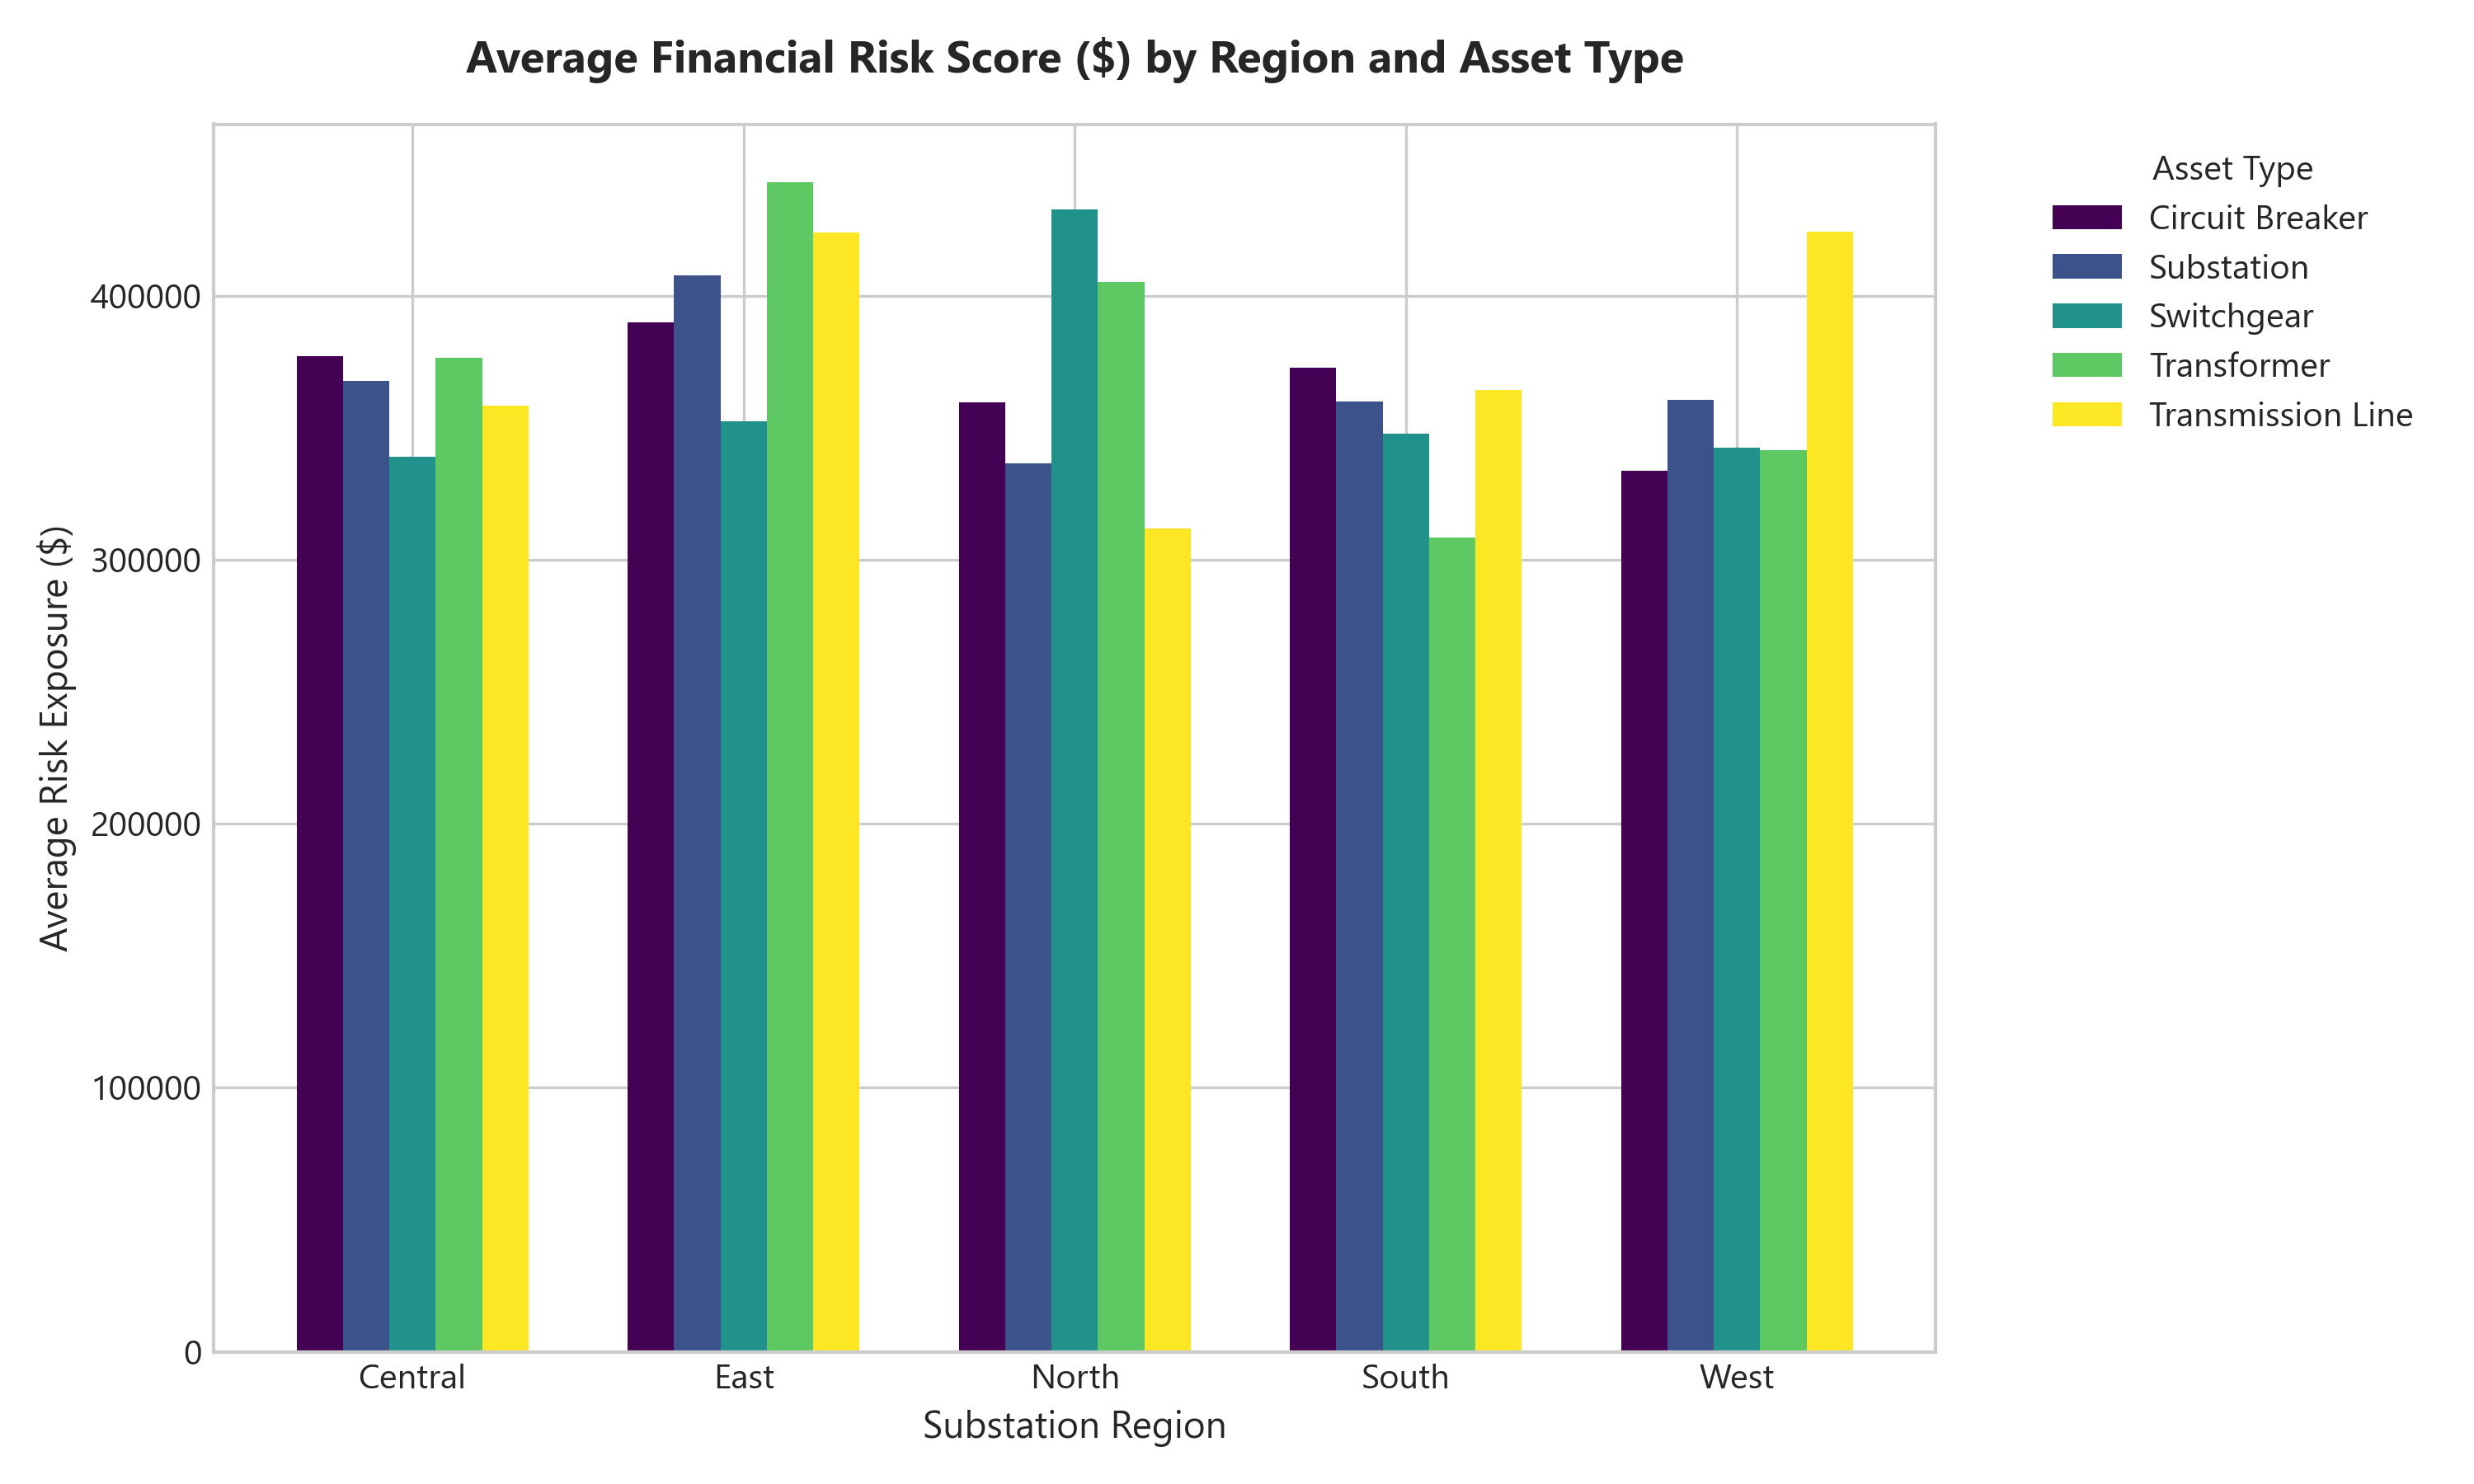

In [5]:
risk_by_region = pd.read_csv(os.path.join(OUTPUT_DIR, 'risk_by_asset_type_region.csv'))
display(risk_by_region.sort_values(by='avg_risk_score', ascending=False).head(10))

print('--- Risk Score Distribution ---')
display(Image(filename=os.path.join(OUTPUT_DIR, 'risk_financial_impact_distribution.png')))